In [1]:
import pandas as pd
df = pd.read_excel('US Superstore data.xls')


In [2]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,33180,South,FUR-FU-10001889,Furniture,Furnishings,Ultra Door Pull Handle,25.2480,3,0.20,4.1028
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,FUR-FU-10000747,Furniture,Furnishings,Tenex B1-RE Series Chair Mats for Low Pile Car...,91.9600,2,0.00,15.6332
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,TEC-PH-10003645,Technology,Phones,Aastra 57i VoIP phone,258.5760,2,0.20,19.3932
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,92627,West,OFF-PA-10004041,Office Supplies,Paper,"It's Hot Message Books with Stickers, 2 3/4"" x 5""",29.6000,4,0.00,13.3200


In [5]:
df.duplicated().sum()
df.drop_duplicates(inplace=True)


In [13]:
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)

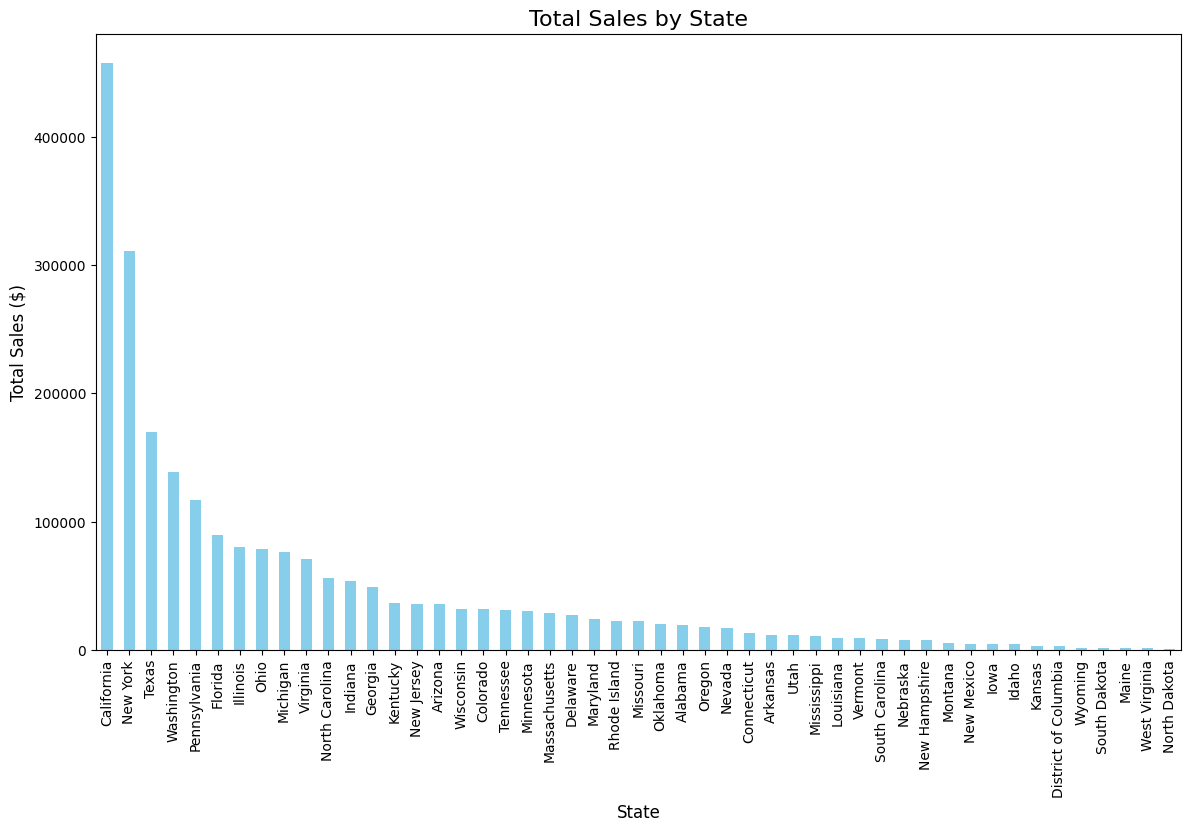

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 8))
state_sales.plot(kind='bar', color='skyblue')
plt.title('Total Sales by State', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.show()

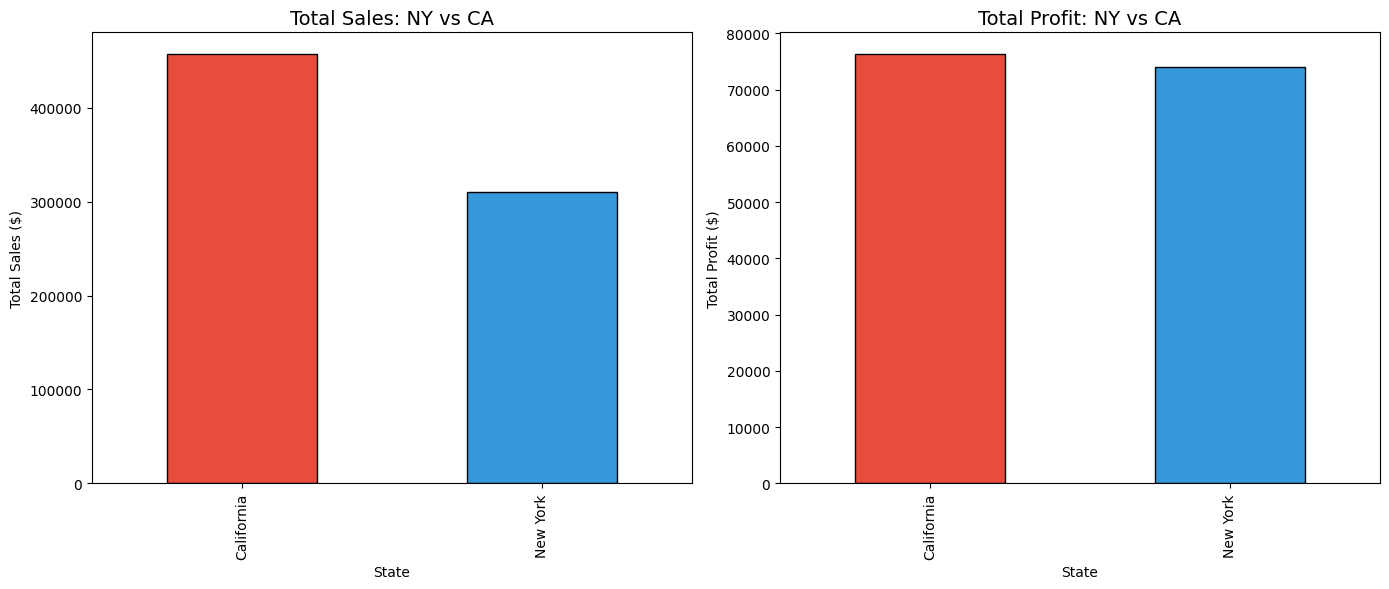

                  Sales      Profit  Profit Margin (%)
State                                                 
California  457687.6315  76381.3871              16.69
New York    310876.2710  74038.5486              23.82


In [22]:
ny_ca = df[df['State'].isin(['New York', 'California'])]
comparison = ny_ca.groupby('State')[['Sales', 'Profit']].sum()
comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Sales comparison
comparison['Sales'].plot(kind='bar', ax=axes[0], color=['#e74c3c', '#3498db'], edgecolor='black')
axes[0].set_title('Total Sales: NY vs CA', fontsize=14)
axes[0].set_ylabel('Total Sales ($)')


# Profit comparison
comparison['Profit'].plot(kind='bar', ax=axes[1], color=['#e74c3c', '#3498db'], edgecolor='black')
axes[1].set_title('Total Profit: NY vs CA', fontsize=14)
axes[1].set_ylabel('Total Profit ($)')


plt.tight_layout()
plt.show()

# Profit margin
comparison['Profit Margin (%)'] = (comparison['Profit'] / comparison['Sales'] * 100).round(2)
print(comparison)

In [23]:
ny_customers = df[df['State'] == 'New York'].groupby('Customer Name').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Num_Orders=('Order ID', 'nunique')
).sort_values('Total_Sales', ascending=False)

In [24]:
ny_customers

,Total_Sales,Total_Profit,Num_Orders
Customer Name,,,
Tom Ashbrook,13723.498,4599.2073,2
Peter Fuller,7678.228,543.2819,1
Seth Vernon,7359.918,1571.7964,1
Tom Boeckenhauer,6999.960,2239.9872,1
Greg Tran,6712.744,774.7935,4
...,...,...,...
Anthony Johnson,4.992,1.6848,1
Quincy Jones,4.950,1.3365,1
Henry MacAllister,4.616,1.7310,1


<Figure size 1400x800 with 0 Axes>

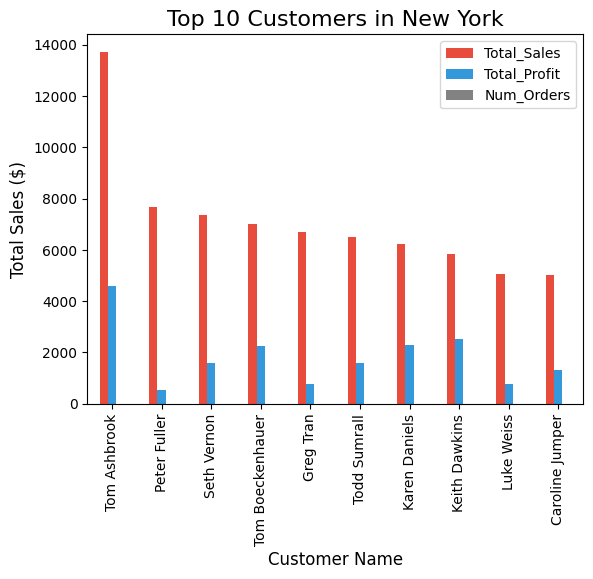

In [29]:
plt.figure(figsize=(14, 8))
top_ny = ny_customers.head(10)
top_ny.plot(kind='bar', color=['#e74c3c', '#3498db', '#828282'])

plt.title('Top 10 Customers in New York', fontsize=16)
plt.xlabel('Customer Name', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.show()

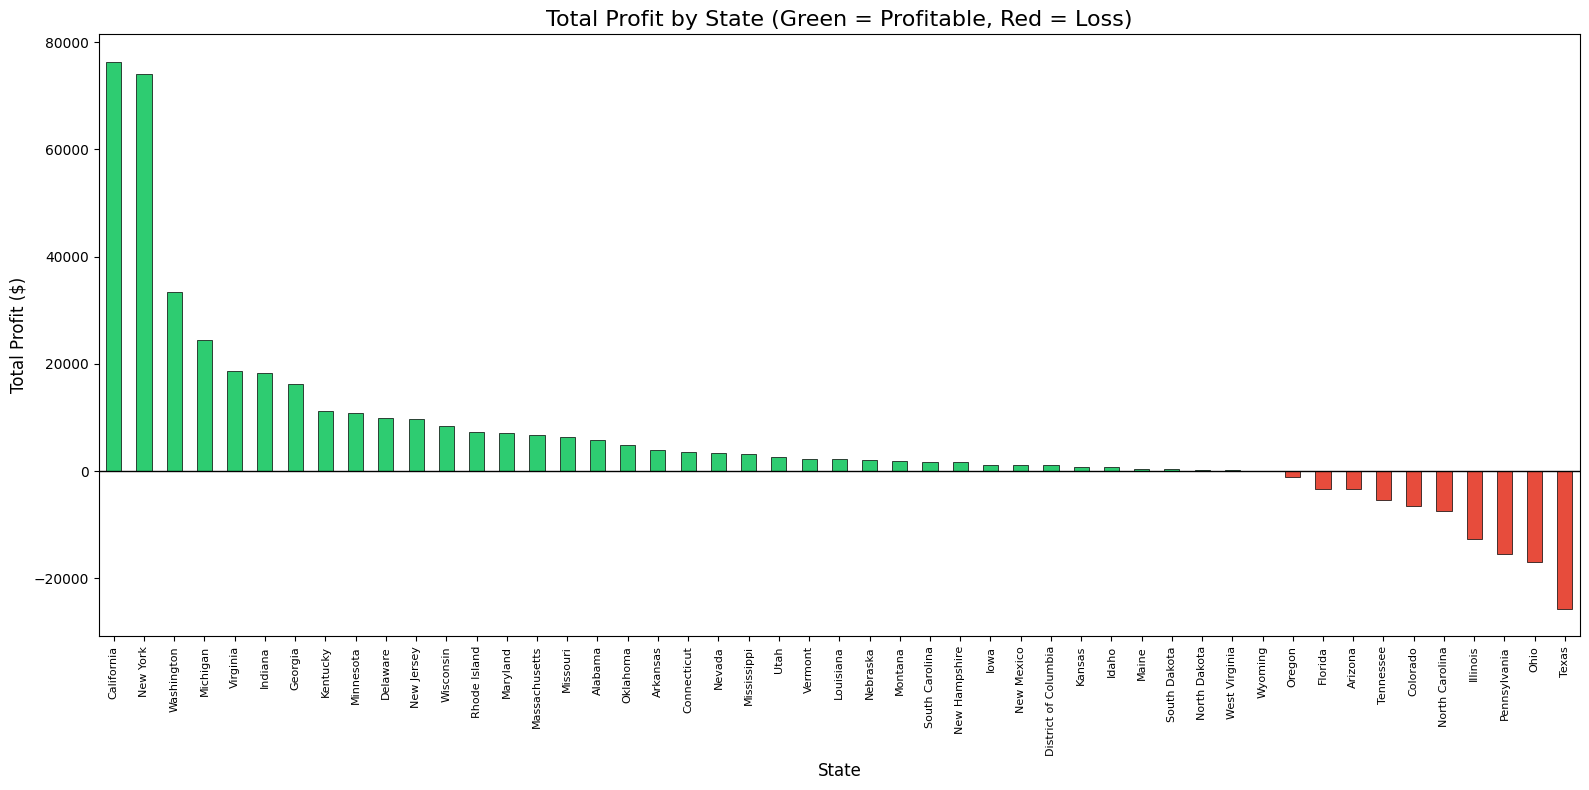

In [30]:
state_profit = df.groupby('State')['Profit'].sum().sort_values(ascending=False)

plt.figure(figsize=(16, 8))
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in state_profit.values]
state_profit.plot(kind='bar', color=colors, edgecolor='black', linewidth=0.5)
plt.title('Total Profit by State (Green = Profitable, Red = Loss)', fontsize=16)
plt.xlabel('State', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.axhline(y=0, color='black', linewidth=1)
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.show()



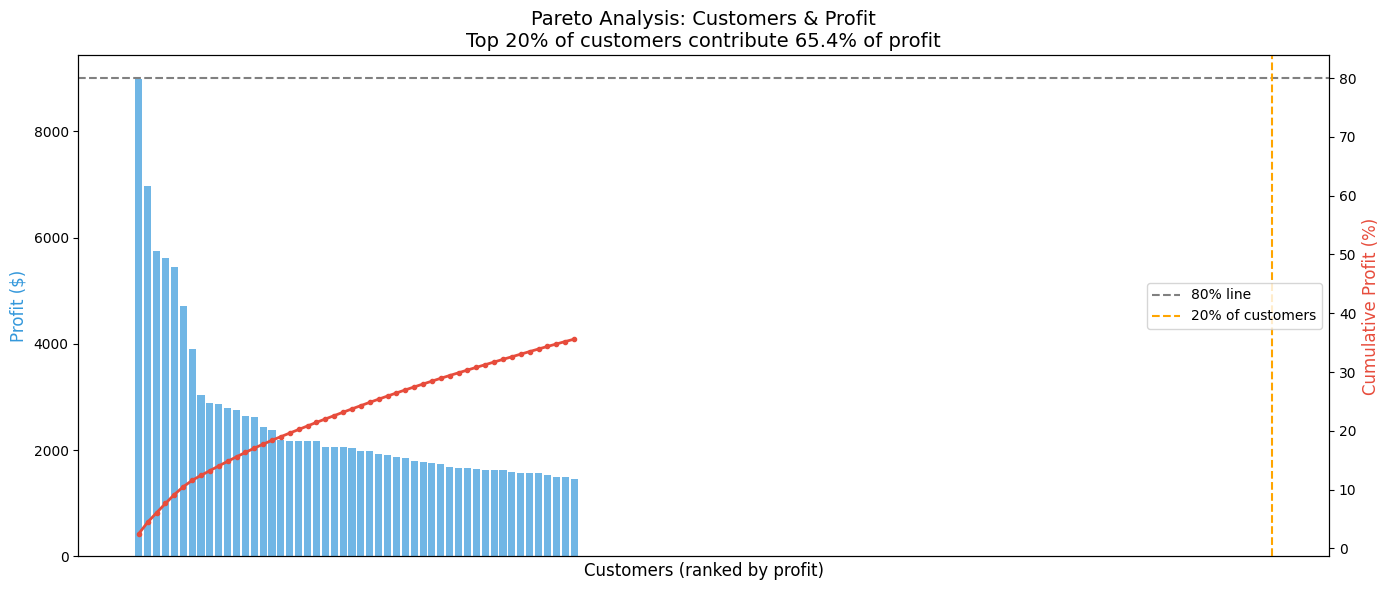

In [32]:
import numpy as np

# Pareto analysis on Customers and Profit
customer_profit = df.groupby('Customer Name')['Profit'].sum().sort_values(ascending=False)

# Only consider profitable customers
profitable_customers = customer_profit[customer_profit > 0].sort_values(ascending=False)
total_positive_profit = profitable_customers.sum()
cumulative_profit = profitable_customers.cumsum() / total_positive_profit * 100

total_customers = len(customer_profit)
top_20_pct_count = int(np.ceil(total_customers * 0.20))
top_20_pct_profit = customer_profit.head(top_20_pct_count).sum()
total_profit = customer_profit[customer_profit > 0].sum()
pct_profit_from_top20 = top_20_pct_profit / total_profit * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart of profit per customer (top 50 for visibility)
ax1.bar(range(len(profitable_customers[:50])), profitable_customers[:50].values, color='#3498db', alpha=0.7)
ax1.set_xlabel('Customers (ranked by profit)', fontsize=12)
ax1.set_ylabel('Profit ($)', fontsize=12, color='#3498db')
ax1.set_xticks([])

# Cumulative line
ax2 = ax1.twinx()
ax2.plot(range(len(cumulative_profit[:50])), cumulative_profit[:50].values, color='#e74c3c', linewidth=2, marker='o', markersize=3)
ax2.set_ylabel('Cumulative Profit (%)', fontsize=12, color='#e74c3c')
ax2.axhline(y=80, color='gray', linestyle='--', label='80% line')
ax2.axvline(x=len(profitable_customers) * 0.20, color='orange', linestyle='--', label='20% of customers')
ax2.legend(loc='center right')

plt.title(f'Pareto Analysis: Customers & Profit\nTop 20% of customers contribute {pct_profit_from_top20:.1f}% of profit', fontsize=14)
plt.tight_layout()
plt.show()


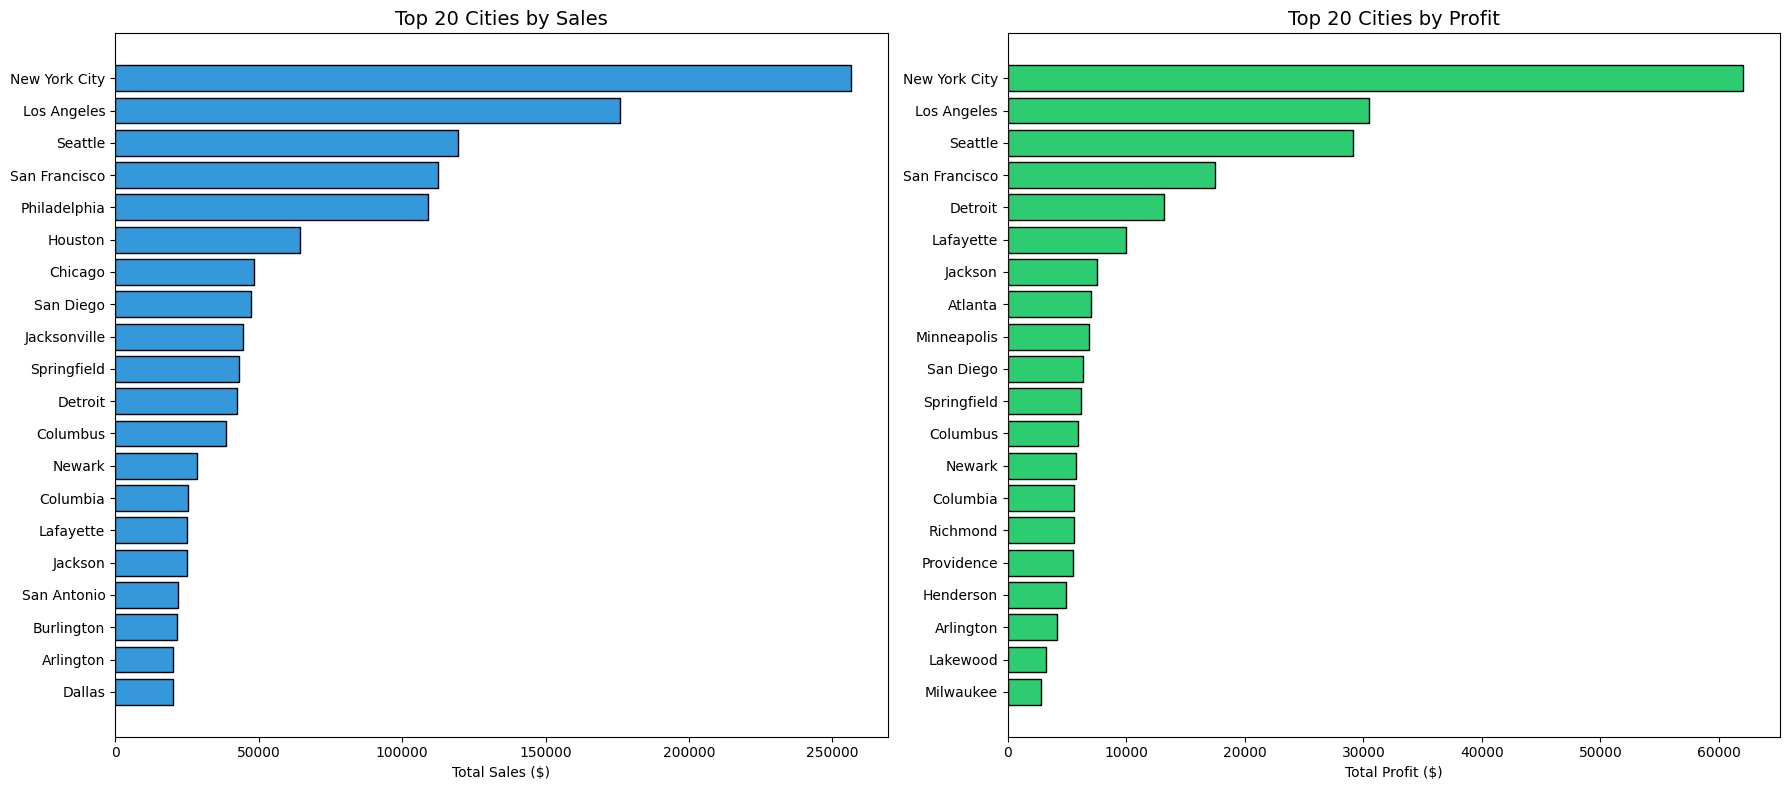

,Profit_Margin_%
0,26.00
1,-270.00
2,-6.84
3,28.56
4,5.77
...,...
526,40.23
527,36.14
528,-12.49
529,26.00


In [34]:
city_stats = df.groupby('City').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum')
).reset_index()
city_stats['Profit_Margin_%'] = (city_stats['Total_Profit'] / city_stats['Total_Sales'] * 100).round(2)

top20_sales = city_stats.nlargest(20, 'Total_Sales')
top20_profit = city_stats.nlargest(20, 'Total_Profit')

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Top 20 by Sales
axes[0].barh(top20_sales['City'], top20_sales['Total_Sales'], color='#3498db', edgecolor='black')
axes[0].set_title('Top 20 Cities by Sales', fontsize=14)
axes[0].set_xlabel('Total Sales ($)')
axes[0].invert_yaxis()

# Top 20 by Profit
colors = ['#2ecc71' if v >= 0 else '#e74c3c' for v in top20_profit['Total_Profit']]
axes[1].barh(top20_profit['City'], top20_profit['Total_Profit'], color=colors, edgecolor='black')
axes[1].set_title('Top 20 Cities by Profit', fontsize=14)
axes[1].set_xlabel('Total Profit ($)')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()
city_stats['Profit_Margin_%']


In [35]:
customer_profit

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
...,...
Henry Goldwyn,-2797.9635
Sharelle Roach,-3333.9144
Luke Foster,-3583.9770


In [40]:
total_customers = len(customer_profit)
top_20_profit_customers = customer_profit.head(20)

In [41]:
top_20_profit_customers

,Profit
Customer Name,
Tamara Chand,8981.3239
Raymond Buch,6976.0959
Sanjit Chand,5757.4119
Hunter Lopez,5622.4292
Adrian Barton,5444.8055
Tom Ashbrook,4703.7883
Christopher Martinez,3899.8904
Keith Dawkins,3038.6254
Andy Reiter,2884.6208


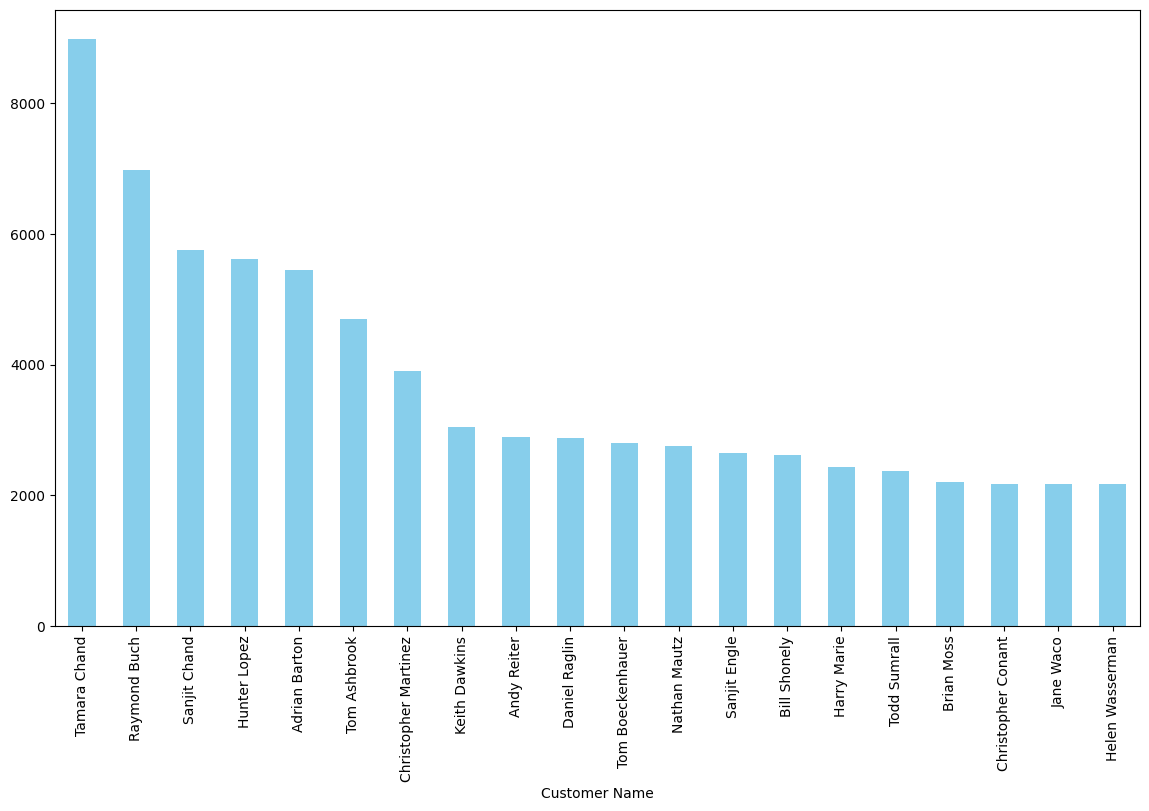

In [43]:
plt.figure(figsize=(14, 8))
top_20_profit_customers.plot(kind='bar', color='skyblue')
plt.show()

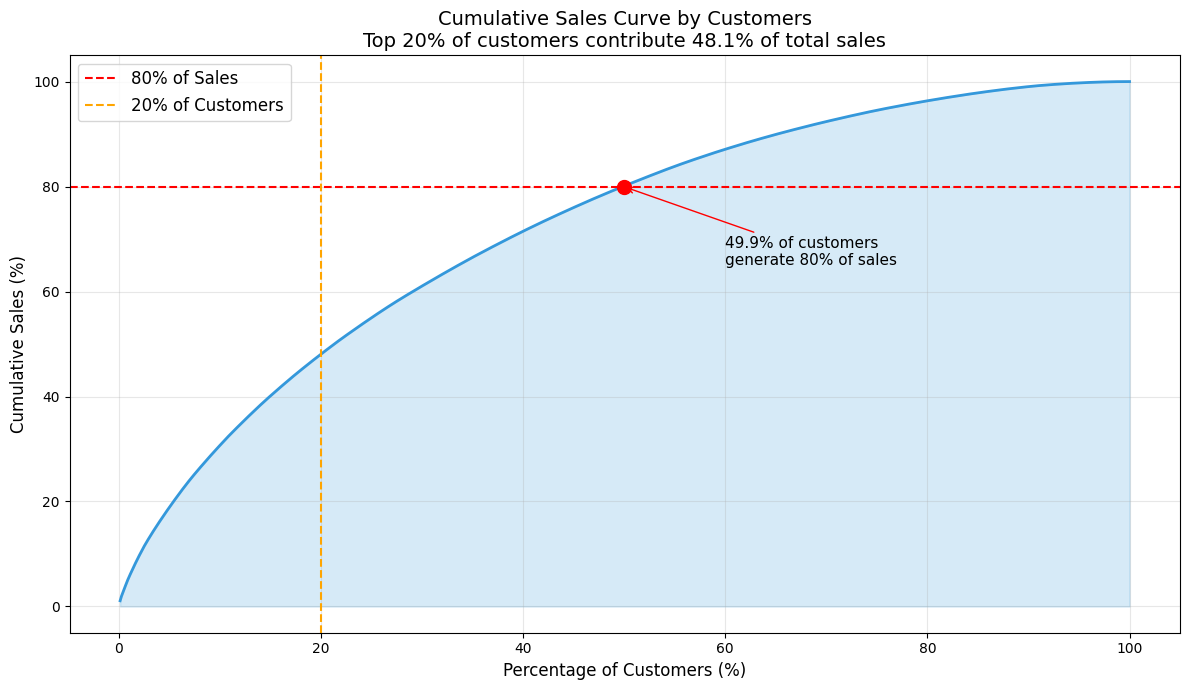

Top 20% of customers (158 customers) contribute 48.1% of total sales
49.9% of customers are needed to reach 80% of total sales

Pareto Principle for Sales: Does not strictly hold


In [44]:
all_customer_sales = df.groupby('Customer Name')['Sales'].sum().sort_values(ascending=False)
total_sales = all_customer_sales.sum()
cumulative_sales = all_customer_sales.cumsum() / total_sales * 100
customer_pct = np.arange(1, len(cumulative_sales) + 1) / len(cumulative_sales) * 100

plt.figure(figsize=(12, 7))
plt.plot(customer_pct, cumulative_sales.values, color='#3498db', linewidth=2)
plt.fill_between(customer_pct, cumulative_sales.values, alpha=0.2, color='#3498db')
plt.axhline(y=80, color='red', linestyle='--', linewidth=1.5, label='80% of Sales')
plt.axvline(x=20, color='orange', linestyle='--', linewidth=1.5, label='20% of Customers')

# Find the actual intersection
idx_80 = np.searchsorted(cumulative_sales.values, 80)
pct_customers_for_80 = customer_pct[idx_80] if idx_80 < len(customer_pct) else 100

plt.scatter([pct_customers_for_80], [80], color='red', s=100, zorder=5)
plt.annotate(f'{pct_customers_for_80:.1f}% of customers\ngenerate 80% of sales',
             xy=(pct_customers_for_80, 80), xytext=(pct_customers_for_80 + 10, 65),
             fontsize=11, arrowprops=dict(arrowstyle='->', color='red'))

# 20% of customers contribute what % of sales?
idx_20 = np.searchsorted(customer_pct, 20)
sales_from_top20 = cumulative_sales.values[idx_20] if idx_20 < len(cumulative_sales) else 100

plt.xlabel('Percentage of Customers (%)', fontsize=12)
plt.ylabel('Cumulative Sales (%)', fontsize=12)
plt.title(f'Cumulative Sales Curve by Customers\nTop 20% of customers contribute {sales_from_top20:.1f}% of total sales', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Top 20% of customers ({int(len(all_customer_sales) * 0.2)} customers) contribute {sales_from_top20:.1f}% of total sales")
print(f"{pct_customers_for_80:.1f}% of customers are needed to reach 80% of total sales")
print(f"\nPareto Principle for Sales: {'Approximately holds' if sales_from_top20 >= 70 else 'Does not strictly hold'}")

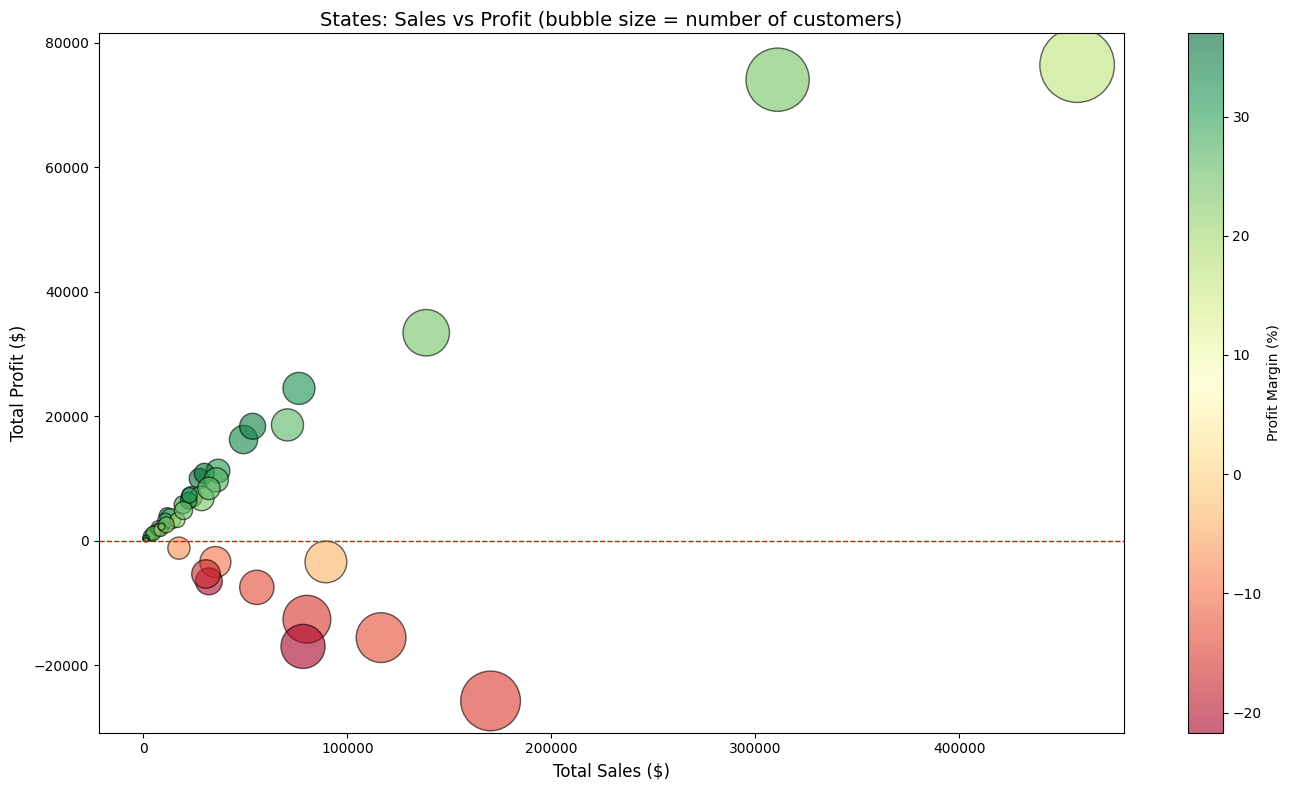

In [48]:
state_full = df.groupby('State').agg(
    Total_Sales=('Sales', 'sum'),
    Total_Profit=('Profit', 'sum'),
    Num_Orders=('Order ID', 'nunique'),
    Num_Customers=('Customer ID', 'nunique')
)
state_full['Profit_Margin_%'] = (state_full['Total_Profit'] / state_full['Total_Sales'] * 100).round(2)
state_full['Avg_Order_Value'] = (state_full['Total_Sales'] / state_full['Num_Orders']).round(2)

# Scatter plot: Sales vs Profit by State
plt.figure(figsize=(14, 8))
scatter = plt.scatter(state_full['Total_Sales'], state_full['Total_Profit'],
                      s=state_full['Num_Customers'] * 5, alpha=0.6, c=state_full['Profit_Margin_%'],
                      cmap='RdYlGn', edgecolor='black')
plt.colorbar(scatter, label='Profit Margin (%)')
plt.axhline(y=0, color='red', linestyle='--', linewidth=1)
plt.xlabel('Total Sales ($)', fontsize=12)
plt.ylabel('Total Profit ($)', fontsize=12)
plt.title('States: Sales vs Profit (bubble size = number of customers)', fontsize=14)

# Label key states
for state in ['California', 'New York', 'Texas', 'Washington', 'Pennsylvania']:
    if state in state_full.index:
        row = state_full.loc[state]
        plt.annotate(state, (row['Total_Sales'], row['Total_Profit']),
                     fontsize=9, fontweight='bold', ha='center', va='bottom')

plt.tight_layout()
plt.show()